 Nesta etapa será feita:

1. Separar X e y
2. Train/Test split
3. Encoding (OneHotEncoder)
4. Treinar modelos (Random Forest recomendado e outros)
5. Avaliar (precision, recall, etc.)
6. Feature importance

In [24]:
# Auto reload
%load_ext autoreload
%autoreload 2

# Import para visualizar as pastas
import os
import sys

# Adiciona a pasta raiz do projeto ao path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Bibliotecas utilizadas
from src.load_data import load_custom_data
from src.save_model import save_model

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ETAPA 1 — MODELING

In [3]:
# 1 - Carrega dataset tratado pelo EDA e separa X e y
df = load_custom_data('dados_tratados.csv')

X = df.drop('loan_status', axis=1)
y = df['loan_status']

Arquivo existe, carregando Dataframe /mnt/SegundoHD/Documentos/Projetos/ChatbotCredito/data/processed/dados_tratados.csv


In [4]:
# 2 - Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify=y Matém proporção de y

In [5]:
# 3 - Separa colunas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns

In [6]:
# 4 - Preprocessing (pipeline base)
preprocessor = ColumnTransformer(transformers=[
                                    ('num', StandardScaler(), num_cols),
                                    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

Iremos utilizar os modelos para o treinamento:
- Random Forest
- Logistic Regression
- Gradient Boosting

In [7]:
# 5 - Pipeline genérico
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', None)]) # placeholder

In [8]:
# 6 - Definir modelos + parâmetros (GridSearch)
param_grid = [
    {
        'model': [RandomForestClassifier(random_state=42)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20]
    },
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': [0.1, 1, 10]
    },
    {
        'model': [GradientBoostingClassifier()],
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1]
    }
]

In [9]:
# 7 - Grid Search
'''
scoring=f1 -> Bom para classificação desbalanceada
n_jobs=-1 -> Usa todos os núcleos do processador, deixa mais rápido
verbose=2 -> mostra progresso detalhado (0 -> silencioso, 1 -> básico, 2 -> detalhado)
'''
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=2
)

In [10]:
# 8 - Treinar
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=None, model__n_estimators=100; total time=   4.7s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=None, model__n_estimators=100; total time=   4.9s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=None, model__n_estimators=100; total time=   4.9s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=None, model__n_estimators=100; total time=   5.0s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=None, model__n_estimators=100; total time=   5.1s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=10, model__n_estimators=100; total time=   4.3s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=10, model__n_estimators=100; total time=   4.0s
[CV] END model=RandomForestClassifier(random_state=42), model__max_depth=10, model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...odel', None)])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [RandomForestC...ndom_state=42)], 'model__max_depth': [None, 10, ...], 'model__n_estimators': [100, 200]}, {'model': [LogisticRegre...max_iter=1000)], 'model__C': [0.1, 1, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, 

In [11]:
# 9 - Melhor modelo
print('Melhor modelo:', grid_search.best_estimator_)
print('Melhores Parâmetros:', grid_search.best_params_)

Melhor modelo: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])
Melhores Parâmetros: {'model': RandomForestClassifier(random_state=42), 'model__max_depth': None, 'model__n_estimators': 200}


# ETAPA 2 - Avaliação do modelo

In [12]:
# 1 - Fazer previsões
y_pred = grid_search.predict(X_test)
# retorna a probabilidade de cair y = 1
y_prob = grid_search.predict_proba(X_test)[:, 1]

In [13]:
# 2 - Métricas principais
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5094
           1       0.97      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.93      0.93      0.93      6515



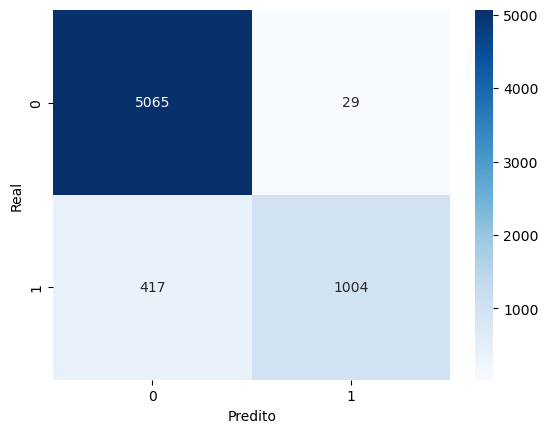

In [14]:
# 3 - Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [15]:
# 4 - ROC AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

ROC AUC: 0.9302979426610822


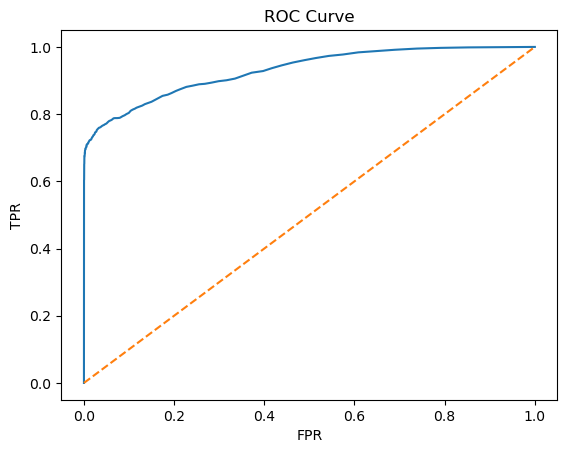

In [16]:
# 4.1 - Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.show()

In [17]:
# 5 - Feature Importance
model = grid_search.best_estimator_.named_steps['model']

importances = model.feature_importances_

In [18]:
# 5.1 - Pegar nomes das features
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

In [19]:
# 5.2 - Visualizar
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                                feature  importance
5              num__loan_percent_income    0.223170
1                    num__person_income    0.143304
4                    num__loan_int_rate    0.105431
3                        num__loan_amnt    0.072905
2                num__person_emp_length    0.059811
10      cat__person_home_ownership_RENT    0.058746
20                    cat__loan_grade_D    0.057322
0                       num__person_age    0.044817
6       num__cb_person_cred_hist_length    0.033606
7   cat__person_home_ownership_MORTGAGE    0.025249


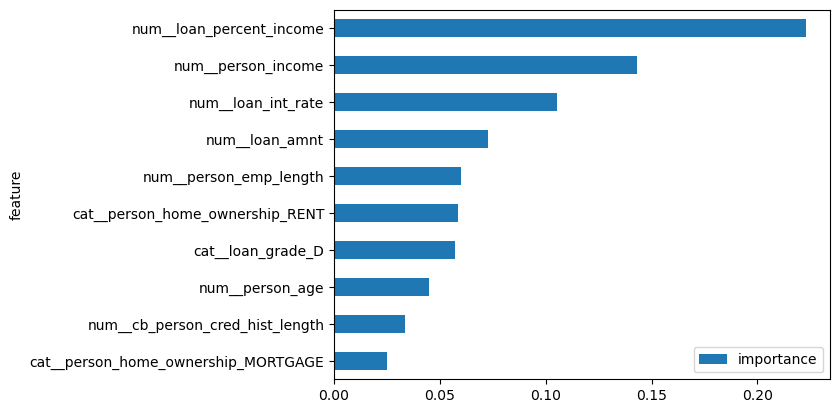

In [20]:
# 5.2 - Plot
feat_imp.head(10).plot(kind='barh', x='feature', y='importance')
plt.gca().invert_yaxis()
plt.show()

# Etapa 3 - Salvar o modelo treinado

In [25]:
# Salvar o modelo treinado
save_model("modelo_credito.pkl", grid_search)


Modelo salvo em: /mnt/SegundoHD/Documentos/Projetos/ChatbotCredito/models/modelo_credito.pkl


# Resumo

Melhor Modelo:
- Modelo: RandomForestClassifier
  - Parâmetros: 
    - random_state=42, 
    - 'model__max_depth': None, 
    - 'model__n_estimators': 200

Pontos fotes:
- Precision classe 1 = 0.97
- ROC AUC = 0.93
- Accuracy = 0.93

Ponto crítico:
- Recall classe 1 = 0.71


O modelo prioriza precisão na identificação de inadimplentes, reduzindo falsos positivos, mas ainda apresenta espaço para melhoria no recall.

Modelo salvo na pasta `models` arquivo `modelo_credito.pkl`.